In [1]:
import tableauhyperapi
print(f"Hyper API Version: {tableauhyperapi.__version__}")

Hyper API Version: 0.0.24457


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pantab, os
from tableauhyperapi import TableName
import kagglehub

path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

# List all files in the dataset folder so you can see what's inside
print("Files in dataset:", os.listdir(path))

# Load the primary Sales Report CSV
csv_file = os.path.join(path, "Amazon Sale Report.csv")
df = pd.read_csv(csv_file, low_memory=False)

print(df.isna().sum()) # check missing values
print(df.describe())
print(df.info())
print('shape: ', {df.shape})
display(df.head())

Files in dataset: ['Amazon Sale Report.csv', 'Cloud Warehouse Compersion Chart.csv', 'P  L March 2021.csv', 'May-2022.csv', 'Sale Report.csv', 'International sale Report.csv', 'Expense IIGF.csv']
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64
               index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  121180.000000

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


/var/folders/ff/lvmqk44s34j0x5n3yv6th4gh0000gn/T/ipykernel_45295/3247894297.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


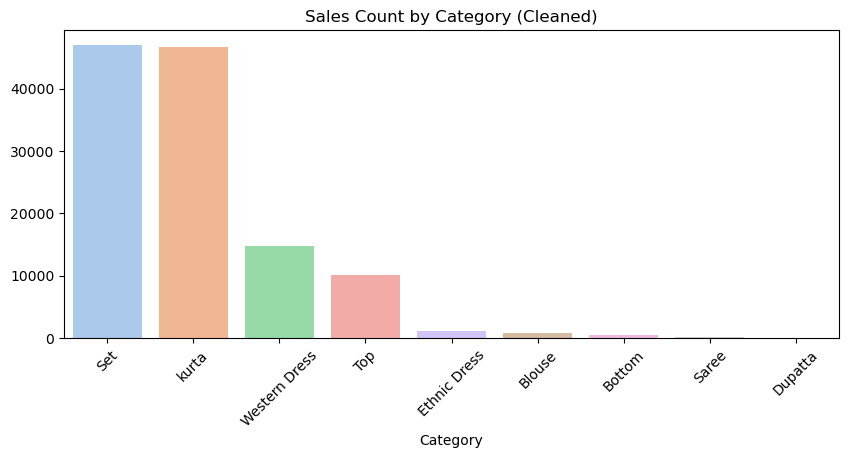

In [4]:
# Handle missing years
df = df.dropna(subset=['Amount'])

# Date: Convert and fill missing dates
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].ffill()

# Categories: Replace NaN with 'Other' so they appear in Tableau filters
df['Category'] = df['Category'].fillna('Other')
df['Courier Status'] = df['Courier Status'].fillna('Unknown')

plt.figure(figsize=(10,4))
sns.barplot(x=df['Category'].value_counts().index, 
            y=df['Category'].value_counts().values,
            palette='pastel',
            hue=df['Category'].value_counts().index
           )
plt.title("Sales Count by Category (Cleaned)")
plt.xticks(rotation=45)
plt.show()

# Export for Tableau Public
pantab.frame_to_hyper(df, "ecommerce_cleaned.hyper", table="AmazonSales") # filename, tablename

## Read back .hyper (Tableau ouptut) with pantab

JupyterLab cannot "open" the file like a dashboard, you can use pantab to read it back into a Pandas DataFrame or use the Hyper Jupyter Kernel to query it using SQL.

In [5]:
# Read a specific table from your .hyper file
df_preview = pantab.frame_from_hyper("ecommerce_cleaned.hyper", table="AmazonSales")

# View the first few rows
df_preview.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22,__index_level_0__
0,15893,171-5906258-3743543,2022-04-21 00:00:00,Shipped,Amazon,Amazon.in,Expedited,J0284,J0284-SKD-XXXL,Set,...,1200.0,MUDIGERE,KARNATAKA,577132.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,<NA>,15893
1,15192,402-0493463-3489942,2022-04-21 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET295,SET295-KR-NP-XXXL,Set,...,751.0,BENGALURU,KARNATAKA,560016.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,<NA>,<NA>,15192
2,15737,407-1694063-8464367,2022-04-21 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET300,SET300-KR-NP-XXXL,Set,...,999.0,BENGALURU,KARNATAKA,560076.0,IN,<NA>,False,<NA>,<NA>,15737
3,15522,408-0570418-3395543,2022-04-21 00:00:00,Shipped,Amazon,Amazon.in,Expedited,SET345,SET345-KR-NP-XXXL,Set,...,626.0,BIDAR,KARNATAKA,585401.0,IN,<NA>,False,<NA>,<NA>,15522
4,14043,406-6710367-4658763,2022-04-22 00:00:00,Shipped,Amazon,Amazon.in,Expedited,J0236,J0236-SKD-XXXL,Set,...,922.0,BENGALURU,KARNATAKA,560067.0,IN,<NA>,False,<NA>,<NA>,14043


# <span style="color:red"> Opens a Tableau-like drag-and-drop interface directly in the Jupyterlab </span>

In [ ]:
import pygwalker as pyg
# This opens a Tableau-like drag-and-drop interface directly in the cell
pyg.walk(df)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064c450d1fce97U61z5kFo3ALTPvE9" style="height: auto">\n    <hea…

## Visualizing SQL Results (Optional)

If you want to use the results of this SQL query back in Seaborn, you can switch back to a Python kernel and use pantab to read the specific SQL result:

        Category        total
0  Western Dress  11216072.69
1   Ethnic Dress    791217.66
2         Bottom    150667.98
3            Set  39204124.03
4          kurta   21299546.7
5        Dupatta        915.0
6            Top    5347792.3
7         Blouse    458408.18
8          Saree    123933.76
Columns in DataFrame: ['Category', 'total']


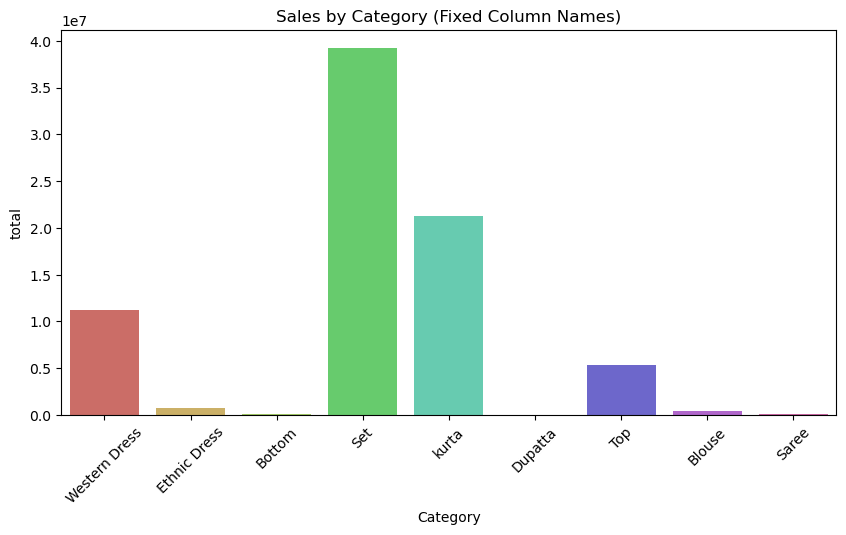

In [7]:
# Back in a Python 3 Kernel
import pantab
import seaborn as sns
import matplotlib.pyplot as plt

# Run the SQL through pantab to get a DataFrame. Use "Category" and "Amount" (Double quotes are key!)
query = 'SELECT "Category", SUM("Amount") as Total FROM "AmazonSales" GROUP BY 1'
df_summary = pantab.frame_from_hyper_query("ecommerce_cleaned.hyper", query)
print(df_summary)
print("Columns in DataFrame:", df_summary.columns.tolist())

category_col = df_summary.columns[0]
value_col = df_summary.columns[1]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_summary, x=category_col, y=value_col, 
            palette='hls', hue=category_col, legend=False)
plt.title(f"Sales by {category_col} (Fixed Column Names)")
plt.xticks(rotation=45)
plt.show()